In [4]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import warnings
import os
warnings.filterwarnings('ignore')

In [5]:
# Load and prepare the data
print("Loading dataset...")

dataset_base_path = r'C:\Users\chinm\Desktop\emotion_detector\Emotion_dataset'
train_path = os.path.join(dataset_base_path, 'train')
test_path = os.path.join(dataset_base_path, 'test')

# Get class names from train folder
class_names = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])
print(f"Found emotion classes: {class_names}")

Loading dataset...
Found emotion classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [10]:
# Function to load images from folders
def load_images_from_folder(base_path, class_names):
    images = []
    labels = []
    
    for idx, emotion in enumerate(class_names):
        emotion_folder = os.path.join(base_path, emotion)
        if os.path.exists(emotion_folder):
            img_count = 0
            for img_file in os.listdir(emotion_folder):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    img_path = os.path.join(emotion_folder, img_file)
                    try:
                        img = load_img(img_path, color_mode='grayscale', target_size=(48, 48))
                        img_array = img_to_array(img) / 255.0
                        images.append(img_array)
                        labels.append(idx)
                        img_count += 1
                    except Exception as e:
                        print(f"Error loading {img_path}: {e}")
            print(f"  Loaded {img_count} images from '{emotion}'")
        else:
            print(f"  Warning: Folder {emotion_folder} not found")
    
    return np.array(images), np.array(labels)

In [11]:
# Load training and test data
print("\nLoading training data...")
X_train, y_train = load_images_from_folder(train_path, class_names)

print("\nLoading test data...")
X_test, y_test = load_images_from_folder(test_path, class_names)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")


Loading training data...
  Loaded 3995 images from 'angry'
  Loaded 436 images from 'disgust'
  Loaded 4097 images from 'fear'
  Loaded 7215 images from 'happy'
  Loaded 4965 images from 'neutral'
  Loaded 4830 images from 'sad'
  Loaded 3171 images from 'surprise'

Loading test data...
  Loaded 958 images from 'angry'
  Loaded 111 images from 'disgust'
  Loaded 1024 images from 'fear'
  Loaded 1774 images from 'happy'
  Loaded 1233 images from 'neutral'
  Loaded 1247 images from 'sad'
  Loaded 831 images from 'surprise'

Training set shape: (28709, 48, 48, 1)
Training labels shape: (28709,)
Test set shape: (7178, 48, 48, 1)
Test labels shape: (7178,)


In [12]:
# Check if data was loaded
if len(X_train) == 0 or len(X_test) == 0:
    print("\n❌ ERROR: No images were loaded!")
    exit()

class_names_display = [name.capitalize() for name in class_names]

# Data augmentation
datagen = ImageDataGenerator(rotation_range=15, width_shift_range=0.1, height_shift_range=0.1, 
                            horizontal_flip=True, zoom_range=0.1)
datagen.fit(X_train)

In [13]:
# Build CNN model
model = keras.Sequential([
    layers.Conv2D(64, 3, activation='relu', input_shape=(48, 48, 1), padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),
    
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),
    
    layers.Conv2D(256, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),
    
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer=keras.optimizers.Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [14]:
# Train model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    validation_data=(X_test, y_test),
    epochs=20,
    callbacks=[
        ModelCheckpoint('best_emotion_model.keras', monitor='val_accuracy', save_best_only=True, mode='max'),
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)
    ]
)

Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 1219s 3s/step - accuracy: 0.2294 - loss: 2.1768 - val_accuracy: 0.2154 - val_loss: 1.8409 - learning_rate: 0.0010
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 918s 2s/step - accuracy: 0.3340 - loss: 1.6981 - val_accuracy: 0.4005 - val_loss: 1.5593 - learning_rate: 0.0010
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 969s 2s/step - accuracy: 0.4332 - loss: 1.4605 - val_accuracy: 0.4476 - val_loss: 1.4372 - learning_rate: 0.0010
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 988s 2s/step - accuracy: 0.4862 - loss: 1.3352 - val_accuracy: 0.5100 - val_loss: 1.3025 - learning_rate: 0.0010
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 1137s 3s/step - accuracy: 0.5186 - loss: 1.2630 - val_accuracy: 0.5362 - val_loss: 1.2475 - learning_rate: 0.0010
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 1128s 3s/step - accuracy: 0.5400 - loss: 1.2127 - val_accuracy: 0.5600 - val_loss: 1.1553 - learning_rate: 0.0010
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 1536s 3s/step - accuracy: 0.5599 - loss

In [15]:

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred_classes = np.argmax(model.predict(X_test), axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=class_names_display))


225/225 ━━━━━━━━━━━━━━━━━━━━ 78s 348ms/step - accuracy: 0.6478 - loss: 0.9445
Test Accuracy: 0.6478
225/225 ━━━━━━━━━━━━━━━━━━━━ 114s 507ms/step

Classification Report:
              precision    recall  f1-score   support

       Angry       0.54      0.64      0.58       958
     Disgust       0.53      0.40      0.45       111
        Fear       0.53      0.35      0.42      1024
       Happy       0.83      0.89      0.86      1774
     Neutral       0.57      0.66      0.61      1233
         Sad       0.54      0.50      0.52      1247
    Surprise       0.77      0.76      0.77       831

    accuracy                           0.65      7178
   macro avg       0.62      0.60      0.60      7178
weighted avg       0.64      0.65      0.64      7178



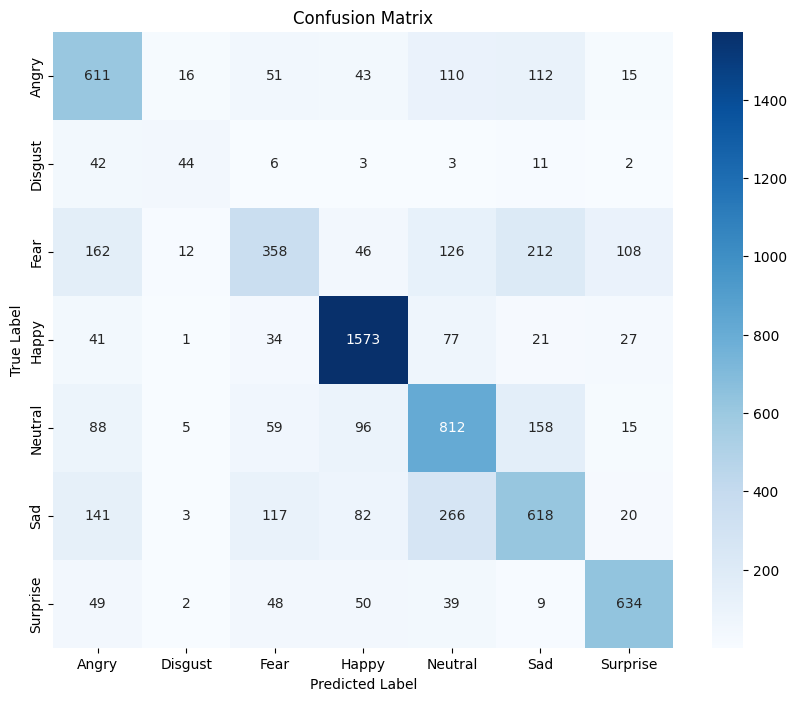

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_display, yticklabels=class_names_display)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png')
plt.show()

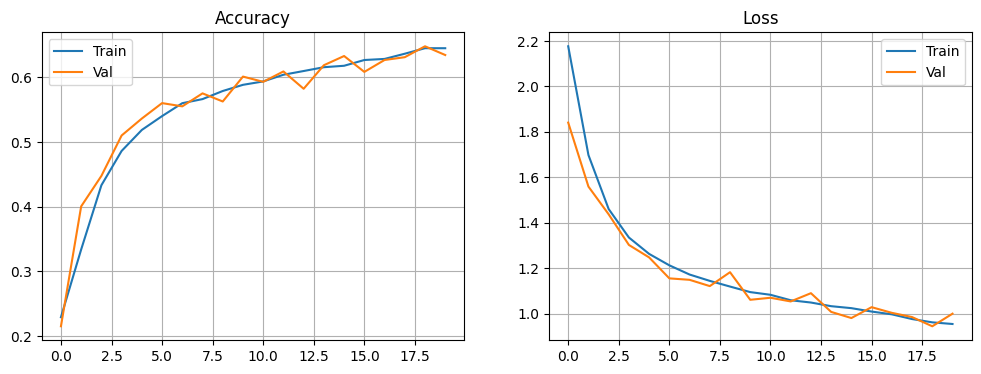

In [17]:
# Training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss')
ax2.legend()
ax2.grid(True)
plt.savefig('training_history.png')
plt.show()

In [19]:
# Real-time detection
print("\n" + "="*50)
print("Starting camera - Press 'q' to quit")
print("="*50)

model = keras.models.load_model("best_emotion_model.keras")
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("❌ Error: Could not open camera")
    exit()

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
        
        face_roi = cv2.resize(gray[y:y+h, x:x+w], (48, 48)).astype("float32") / 255.0
        pred = model.predict(face_roi.reshape(1, 48, 48, 1), verbose=0)
        idx = np.argmax(pred)
        
        cv2.putText(frame, f"{class_names_display[idx]} {pred[0][idx]:.2f}", 
                   (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
    
    cv2.imshow("Emotion Detector", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("\nEmotion detection ended!")


Starting camera - Press 'q' to quit

Emotion detection ended!
